## 1 Create Data


### Load and combine original

In [ ]:
from scripts.data_operation import *

save_data_frame(
    combine_original_data(ORIGINAL_DATA_DIR), 
    filename='combined_data.csv'
)

### Prepare relevant data

In [ ]:
import pandas as pd

from scripts.data_operation import *
from scripts.constants import *

clean_data = pd.read_csv('data/combined_data.csv')

distinct_listings = clean_data['apartment_id'].unique()
listing_indices = {listing: i for i, listing in enumerate(distinct_listings)}

clean_data['apartment_id'] = clean_data['apartment_id'].map(listing_indices)
clean_data['adults_count'] = clean_data['adults_count'].fillna(0).astype(int)
clean_data['children_count'] = clean_data['children_count'].fillna(0).astype(int)
clean_data['infants_count'] = clean_data['infants_count'].fillna(0).astype(int)
clean_data['start_date'] = pd.to_datetime(clean_data['start_date'], errors='coerce')
clean_data['end_date'] = pd.to_datetime(clean_data['end_date'], errors='coerce')
clean_data['price'] = earnings_to_numbers(clean_data['earnings'])
clean_data['beds_count'] = clean_data['adults_count'] + clean_data['children_count'] + clean_data['infants_count']

clean_data['nightly_rate'] = (clean_data['price'] / clean_data['nights_count']).round(0).astype(int)
clean_data['nightly_bed_rate'] = (clean_data['nightly_rate'] / clean_data['beds_count']).round(0).astype(int)

save_data_frame(
    clean_data[RELEVANT_COLUMNS], 
    filename='relevant_data.csv'
)

### Prepare demand data

In [ ]:
import pandas as pd

from scripts.data_operation import *
from scripts.constants import *


relevant_data = pd.read_csv('data/relevant_data.csv', parse_dates=['start_date', 'end_date'])

daily_stays = pd.DataFrame(transform_to_daily_stays(relevant_data))

listing_summary = relevant_data.groupby('apartment_id').agg(
    avg_nightly_rate=('nightly_rate', 'mean'),
    avg_bed_rate=('nightly_bed_rate', 'mean'),
    avg_people_count=('beds_count', 'mean'),
    max_people_count=('beds_count', 'max'),
    num_reservations=('apartment_id', 'count')
).reset_index()

total_beds = listing_summary['max_people_count'].sum()

daily_agg = daily_stays.groupby('stay_date').agg(
    room_nights=('beds_count', 'sum'),
    occupied_apartments=('apartment_id', lambda x: list(x)),
    apartment_bed_rate_pairs=('apartment_bed_rate_pair', lambda x: list(x)),
    avg_bed_rate=('nightly_bed_rate', lambda x: int(round(x.mean()))),
    sum_bed_rate=('nightly_bed_rate', 'sum'),
    occupancy_rate=('beds_count', lambda x: round(x.sum() / total_beds, 4))
)

daily_agg = daily_agg.reset_index()
daily_agg['stay_date'] = pd.to_datetime(daily_agg['stay_date'], errors='coerce')
daily_agg = daily_agg[(daily_agg['stay_date'] >= START_DATE) & (daily_agg['stay_date'] < END_DATE)]

save_data_frame(
    daily_agg,
    filename='daily_aggregated_data.csv'
)

save_data_frame(
    listing_summary,
    filename='listing_summary.csv'
)


## 2 Data Display

### Listing summary

Data saved to data\listing_summary.csv


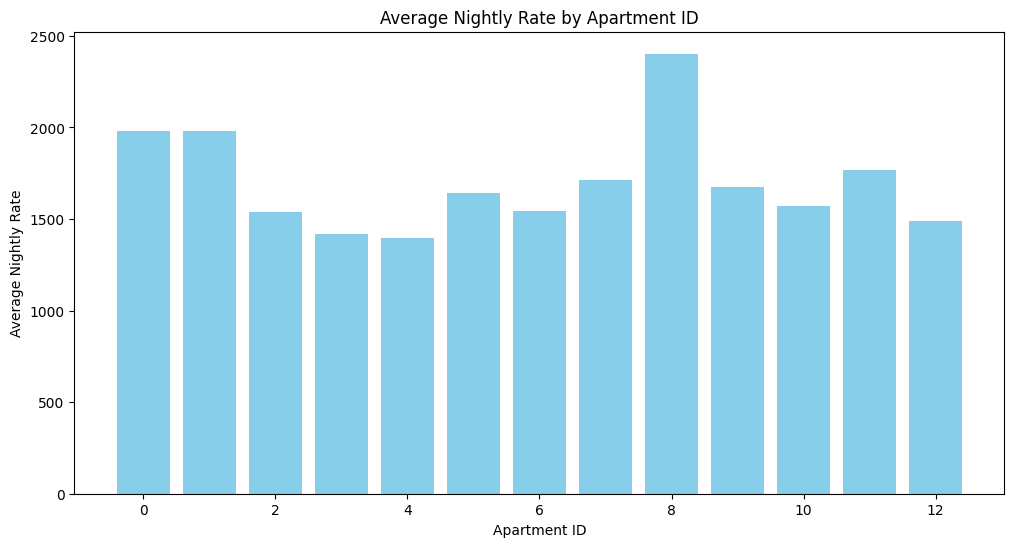

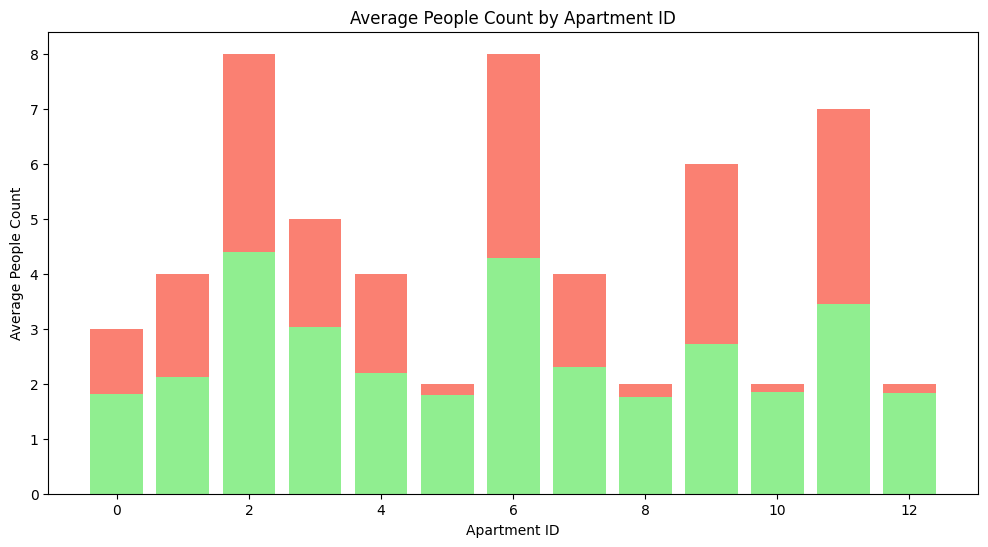

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scripts.data_operation import *
from scripts.constants import *

relevant_data = pd.read_csv('data/relevant_data.csv')

listing_summary = relevant_data.groupby('apartment_id').agg(
    avg_nightly_rate=('nightly_rate', 'mean'),
    avg_bed_rate=('nightly_bed_rate', 'mean'),
    max_bed_rate=('nightly_bed_rate', 'max'),
    min_bed_rate=('nightly_bed_rate', 'min'),
    bed_rate_ratio=('nightly_bed_rate', lambda x: x.max() / x.min() if x.min() > 0 else None),
    min_avg_bed_rate_ratio=('nightly_bed_rate', lambda x: x.min() / x.mean() if x.mean() > 0 else None),
    max_avg_bed_rate_ratio=('nightly_bed_rate', lambda x: x.max() / x.mean() if x.mean() > 0 else None),
    avg_people_count=('beds_count', 'mean'),
    max_people_count=('beds_count', 'max'),
    num_reservations=('apartment_id', 'count')
).reset_index()

save_data_frame(
    listing_summary,
    filename='listing_summary.csv'
)

plt.figure(figsize=(12, 6))
plt.bar(listing_summary['apartment_id'], (listing_summary['avg_bed_rate'])/100, color='skyblue')
plt.xlabel('Apartment ID')
plt.ylabel('Average Nightly Rate')
plt.title('Average Nightly Rate by Apartment ID')
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(listing_summary['apartment_id'], listing_summary['max_people_count'], color='salmon')
plt.bar(listing_summary['apartment_id'], listing_summary['avg_people_count'], color='lightgreen')
plt.xlabel('Apartment ID')
plt.ylabel('Average People Count')
plt.title('Average People Count by Apartment ID')
plt.show()

### Agregated data

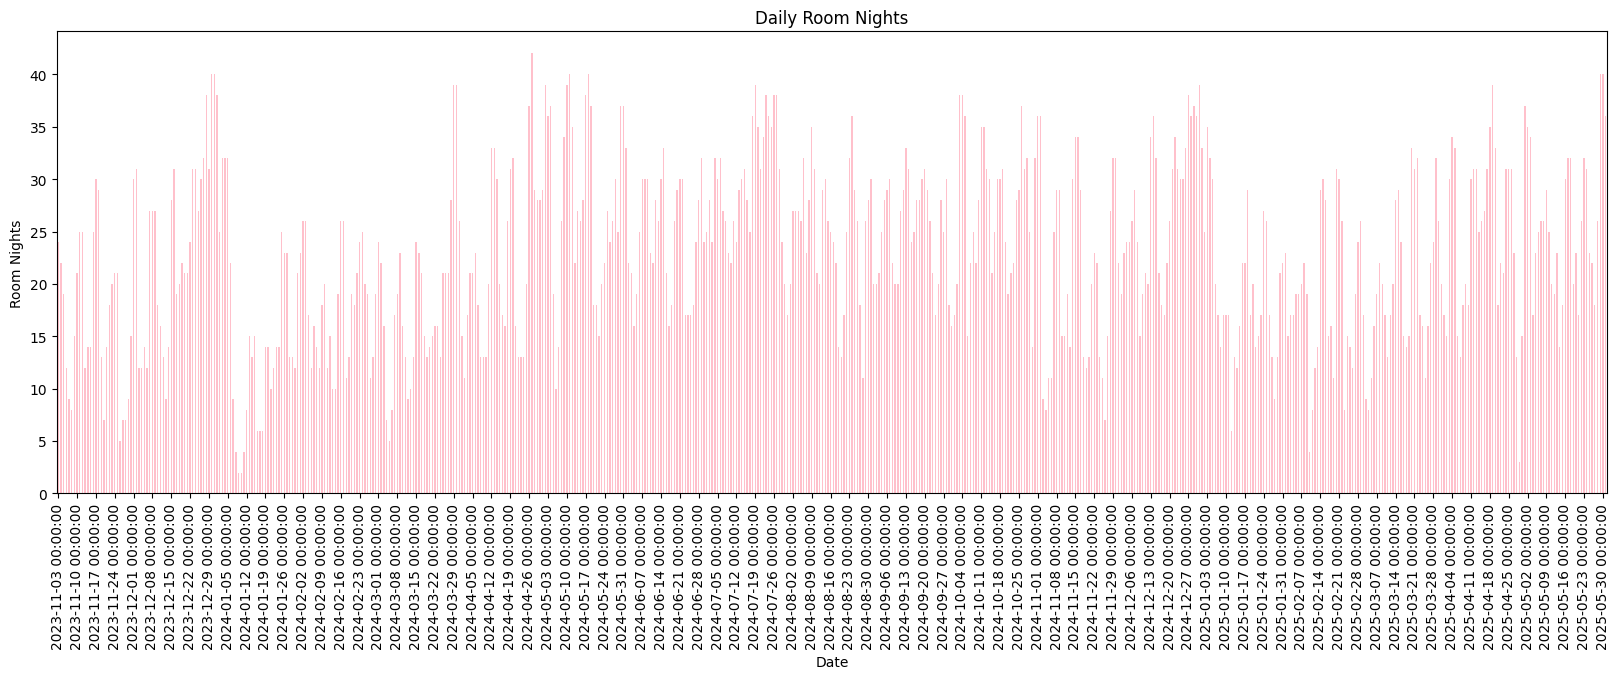

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from scripts.data_operation import *

daily_agg = pd.read_csv('data/daily_aggregated_data.csv', parse_dates=['stay_date'])
daily_agg.set_index('stay_date', inplace=True)
# bar plot of daily room nights
daily_agg['room_nights'].plot(figsize=(20, 6), kind='bar', title='Daily Room Nights', color='pink')
plt.xticks(ticks=range(0, len(daily_agg), 7))
plt.xlabel('Date')
plt.ylabel('Room Nights')
plt.show()

## 3 Data correlation

📊 Pearson correlation: 0.427  (p = 0.0 )
📊 Spearman correlation: 0.41  (p = 0.0 )


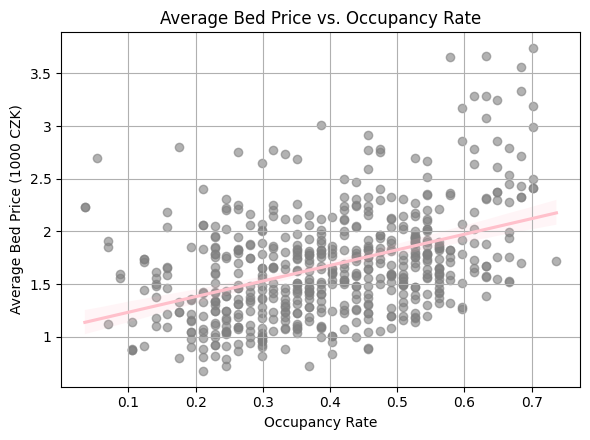

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

daily_df = pd.read_csv('data/daily_aggregated_data.csv', parse_dates=['stay_date'])

# Calculate Pearson and Spearman correlations
pearson_corr, pearson_p = pearsonr(daily_df['occupancy_rate'], daily_df['avg_bed_rate'])
spearman_corr, spearman_p = spearmanr(daily_df['occupancy_rate'], daily_df['avg_bed_rate'])
print("📊 Pearson correlation:", round(pearson_corr, 3), " (p =", round(pearson_p, 4), ")")
print("📊 Spearman correlation:", round(spearman_corr, 3), " (p =", round(spearman_p, 4), ")")

# === Plotting ===
plt.figure(figsize=(6, 4.5))
ax = sns.regplot(
    x='occupancy_rate',
    y='avg_bed_rate',
    data=daily_df,
    scatter_kws={'alpha': 0.6, 'color': 'gray'},
    line_kws={'color': 'pink'}
)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y / 100000:g}'))
plt.title('Average Bed Price vs. Occupancy Rate')
plt.xlabel('Occupancy Rate')
plt.ylabel('Average Bed Price (1000 CZK)')
plt.grid(True)
plt.tight_layout()
plt.show()
